<a href="https://colab.research.google.com/github/Tauhid-Topu-007/Chest-X-Ray-Pneumonia-Covid-19-Tuberculosis--VGG16/blob/main/VGG16_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir ~/.kaggle

In [ ]:
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download jtiptj/chest-xray-pneumoniacovid19tuberculosis

Dataset URL: https://www.kaggle.com/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis
License(s): other
100% 1.74G/1.74G [00:23<00:00, 80.5MB/s]



In [ ]:
!unzip /content/chest-xray-pneumoniacovid19tuberculosis.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/NORMAL/NORMAL2-IM-0843-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0845-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0846-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0847-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0848-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0849-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0851-0001-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0851-0001-0002.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0851-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0852-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0853-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0854-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0855-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0856-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0857-0001.j

In [ ]:
!pip3 install tensorflow numpy matplotlib keras

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Rescaling

# For reproducibility
import numpy as np
import random
import os

seed = 123

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
## Directories containing the datasets
train_dir='/content/train'
val_dir='/content/val'
test_dir='/content/test'

#Hyperparameter
img_width,img_height=224,224
batch_size=32
epochs=20
num_classes=4

In [ ]:
# Load training dataset (NO validation split)
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_width, img_height),
    batch_size=batch_size,
)

Found 6326 files belonging to 4 classes.


In [ ]:
# Load validation dataset
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(img_width, img_height),
    batch_size=batch_size,
)

Found 38 files belonging to 4 classes.


In [ ]:
# Test dataset
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_width, img_height),
    batch_size=batch_size,
)

Found 771 files belonging to 4 classes.


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [ ]:
# Apply data augmentation only to the training data
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

In [ ]:
# prefetch the dataset for better performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [ ]:
def build_vgg16(input_shape=(224, 224, 3), num_classes=4):

    model = models.Sequential()

    # Input Layer
    model.add(layers.Input(shape=input_shape))

    # Normalization
    model.add(Rescaling(1./255))

    # Block 1
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))

    # Block 2

    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))


    # Block 3
    model.add(layers.Conv2D(256, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(256, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(256, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))

    # Block 4
    model.add(layers.Conv2D(512, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(512, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(512, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))

    # Block 5
    model.add(layers.Conv2D(512, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(512, (3, 3), padding="same", activation="relu"))
    model.add(layers.Conv2D(512, (3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2, 2), strides=(2, 2)))

    # Fully Connected Layers

    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(4096, activation="relu"))
    model.add(layers.Dropout(0.5))

    # Output Layer
    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

In [ ]:
model=build_vgg16(num_classes=num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        16,38

 Total params: 134,276,932 (512.23 MB)

 Trainable params: 134,276,932 (512.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
              )

In [ ]:
history=model.fit(
      train_dataset,
      epochs=epochs,
      validation_data=validation_dataset
  )

Epoch 1/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.6002 - loss: 1.1318 - val_accuracy: 0.2105 - val_loss: 1.8396
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 143s 720ms/step - accuracy: 0.6126 - loss: 1.0600 - val_accuracy: 0.2105 - val_loss: 1.8174
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 149s 751ms/step - accuracy: 0.6126 - loss: 1.0601 - val_accuracy: 0.2105 - val_loss: 1.8495
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 200s 740ms/step - accuracy: 0.6126 - loss: 1.0595 - val_accuracy: 0.2105 - val_loss: 1.8136
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 150s 754ms/step - accuracy: 0.6126 - loss: 1.0607 - val_accuracy: 0.2105 - val_loss: 1.8053
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 196s 728ms/step - accuracy: 0.6126 - loss: 1.0589 - val_accuracy: 0.2105 - val_loss: 1.8100
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 145s 730ms/step - accuracy: 0.6126 - loss: 1.0593 - val_accuracy: 0.2105 - val_loss: 1.8025
Epoch 8/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 142s 716ms/step - accuracy: 0.6126 - lo

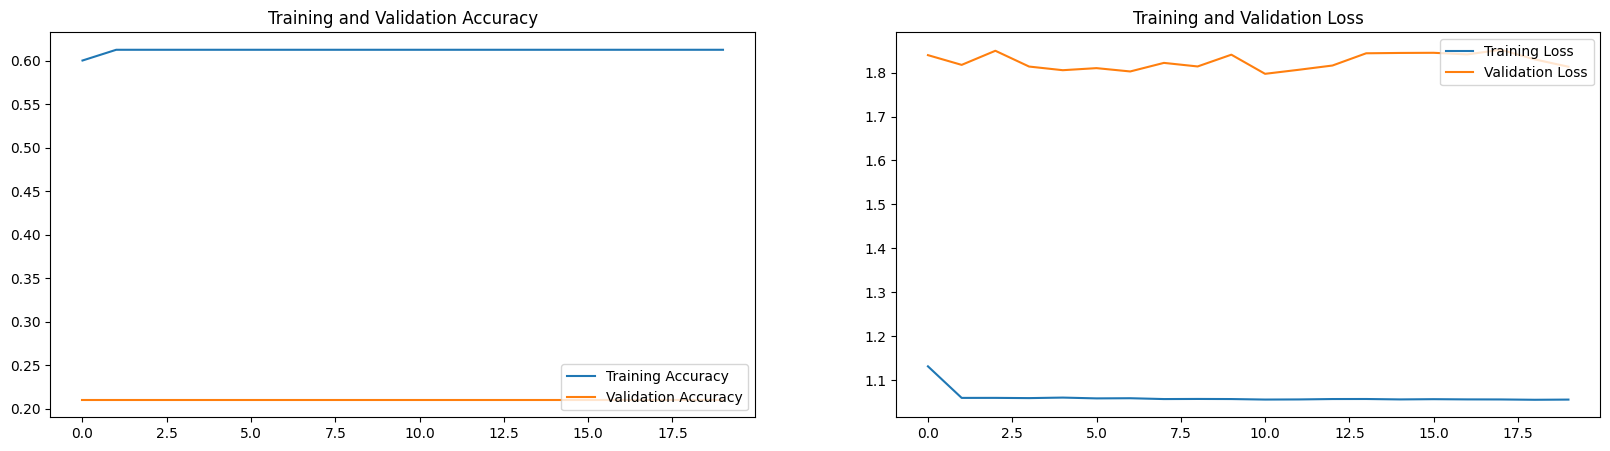

In [ ]:
import matplotlib.pyplot as plt

# Extract metrics from history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Number of epochs
epochs_range = range(len(acc))

# Plotting
plt.figure(figsize=(20, 5))


# Accuracy Plot

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')


# Loss Plot

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
test_loss,test_accuracy=model.evaluate(test_dataset)
print(f"Test Accuracy: {test_accuracy *100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 422ms/step - accuracy: 0.5058 - loss: 1.2011
Test Accuracy: 50.58%


In [ ]:
# Train set prediction
# True labels (y_train_true)
y_train_true = np.concatenate([y for x, y in train_dataset], axis=0)

# Predicted probabilities
y_train_pred_probs = model.predict(train_dataset)

# Convert to class labels
y_train_pred = np.argmax(y_train_pred_probs, axis=1)

198/198 ━━━━━━━━━━━━━━━━━━━━ 119s 593ms/step


In [ ]:
# Validation set prediction
# True labels (y_val_true)
y_val_true = np.concatenate([y for x, y in validation_dataset], axis=0)

# Predicted probabilities
y_val_pred_probs = model.predict(validation_dataset)

# Convert to class labels
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 497ms/step


In [ ]:
# Test set prediction
# True labels (y_test_true)
y_test_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Predicted probabilities
y_test_pred_probs = model.predict(test_dataset)

# Convert to class labels
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 310ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

# Training confusion matrix
cm_train = confusion_matrix(y_train_true, y_train_pred)

# Validation confusion matrix
cm_val = confusion_matrix(y_val_true, y_val_pred)

# Test confusion matrix
cm_test = confusion_matrix(y_test_true, y_test_pred)

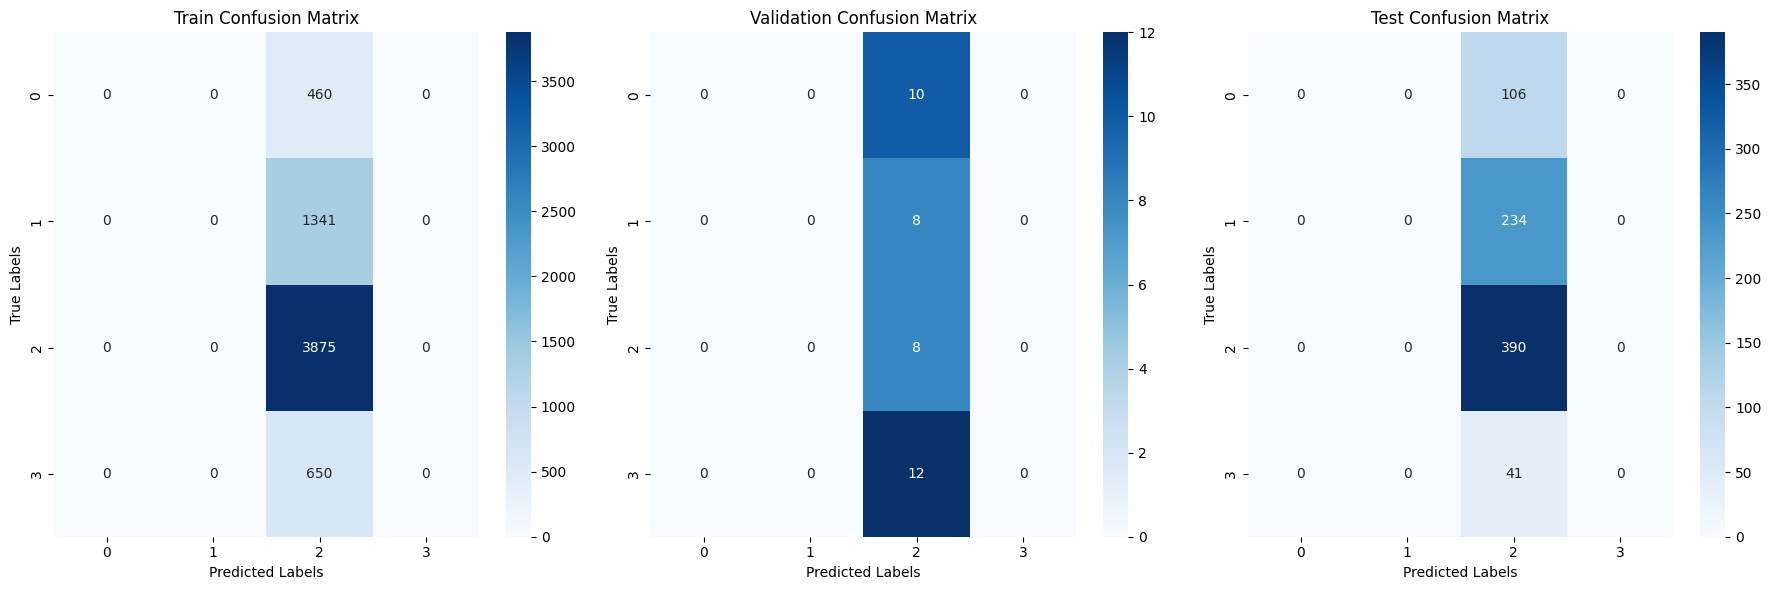

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


# Train Confusion Matrix

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted Labels")
axes[0].set_ylabel("True Labels")


# Validation Confusion Matrix

sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted Labels")
axes[1].set_ylabel("True Labels")


# Test Confusion Matrix

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title("Test Confusion Matrix")
axes[2].set_xlabel("Predicted Labels")
axes[2].set_ylabel("True Labels")

plt.tight_layout()
plt.show()

## Concept of Transfer learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Input



In [ ]:
# Load VGG16 with pretrained ImageNet weights, without top layers
base_model = VGG16(
    weights=None,
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)

# Show model summary
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Image dimensions
img_width = 224
img_height = 224

# Load VGG16 with pretrained ImageNet weights, without top layers
base_model = VGG16(
    weights='imagenet',      # lowercase!
    include_top=False,
    input_tensor=Input(shape=(img_width, img_height, 3))
)

# Show model summary
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
# Build the full model

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")  # Output layer
])

In [ ]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',  # Use 'categorical_crossentropy' if labels are one-hot
    metrics=['accuracy']
)

## Transfer learning with fixed weight in convultion and training model on FC layers

In [ ]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 96s 468ms/step - accuracy: 0.8375 - loss: 2.1039 - val_accuracy: 0.8684 - val_loss: 0.7555
Epoch 2/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 136s 449ms/step - accuracy: 0.9004 - loss: 0.5565 - val_accuracy: 0.7895 - val_loss: 0.7024
Epoch 3/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 142s 451ms/step - accuracy: 0.9099 - loss: 0.3580 - val_accuracy: 0.8421 - val_loss: 0.4083
Epoch 4/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 142s 454ms/step - accuracy: 0.9148 - loss: 0.2883 - val_accuracy: 0.8947 - val_loss: 0.3962
Epoch 5/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 90s 452ms/step - accuracy: 0.9243 - loss: 0.2372 - val_accuracy: 0.9211 - val_loss: 0.4318
Epoch 6/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 143s 455ms/step - accuracy: 0.9349 - loss: 0.2107 - val_accuracy: 0.9211 - val_loss: 0.4901
Epoch 7/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 89s 450ms/step - accuracy: 0.9366 - loss: 0.2050 - val_accuracy: 0.8947 - val_loss: 0.2539
Epoch 8/10
198/198 ━━━━━━━━━━━━━━━━━━━━ 142s 451ms/step - accuracy: 0.9410 - lo

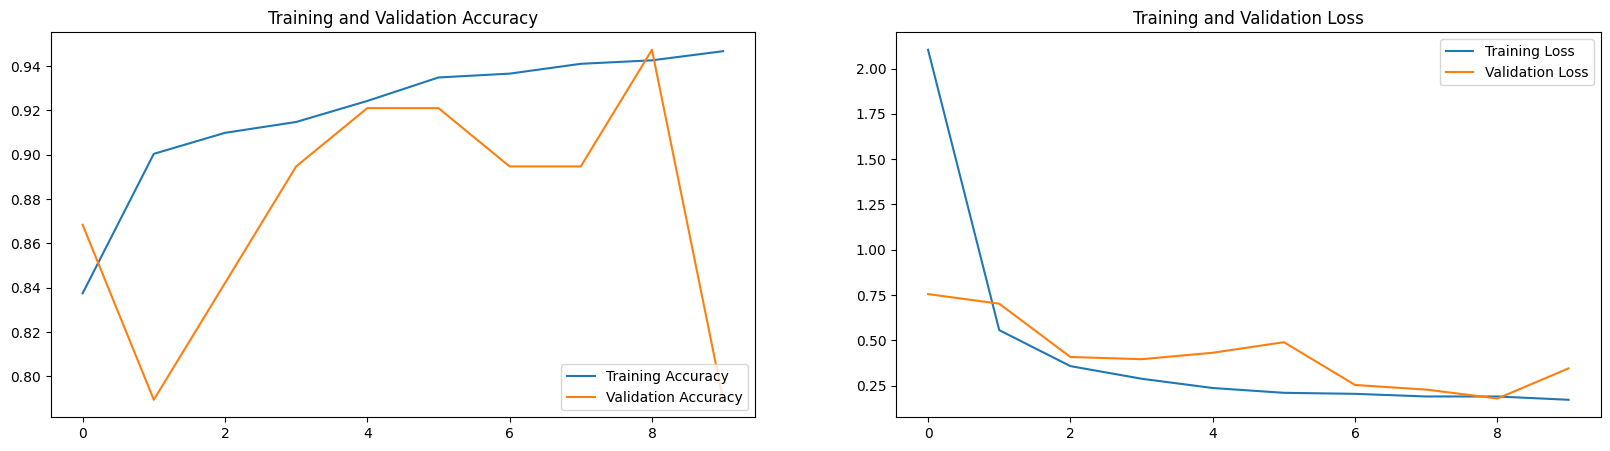

In [ ]:
import matplotlib.pyplot as plt

# Extract metrics from history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Number of epochs
epochs_range = range(len(acc))

# Plotting
plt.figure(figsize=(20, 5))


# Accuracy Plot

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')


# Loss Plot

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
test_loss,test_accuracy=model.evaluate(test_dataset)
print(f"Test Accuracy: {test_accuracy *100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 478ms/step - accuracy: 0.8042 - loss: 1.0038
Test Accuracy: 80.42%


In [ ]:
# Train set prediction
# True labels (y_train_true)
y_train_true = np.concatenate([y for x, y in train_dataset], axis=0)

# Predicted probabilities
y_train_pred_probs = model.predict(train_dataset)

# Convert to class labels
y_train_pred = np.argmax(y_train_pred_probs, axis=1)

198/198 ━━━━━━━━━━━━━━━━━━━━ 97s 480ms/step


In [ ]:
# Validation set prediction
# True labels (y_val_true)
y_val_true = np.concatenate([y for x, y in validation_dataset], axis=0)

# Predicted probabilities
y_val_pred_probs = model.predict(validation_dataset)

# Convert to class labels
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 471ms/step


In [ ]:
# Test set prediction
# True labels (y_test_true)
y_test_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Predicted probabilities
y_test_pred_probs = model.predict(test_dataset)

# Convert to class labels
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 382ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

# Training confusion matrix
cm_train = confusion_matrix(y_train_true, y_train_pred)

# Validation confusion matrix
cm_val = confusion_matrix(y_val_true, y_val_pred)

# Test confusion matrix
cm_test = confusion_matrix(y_test_true, y_test_pred)

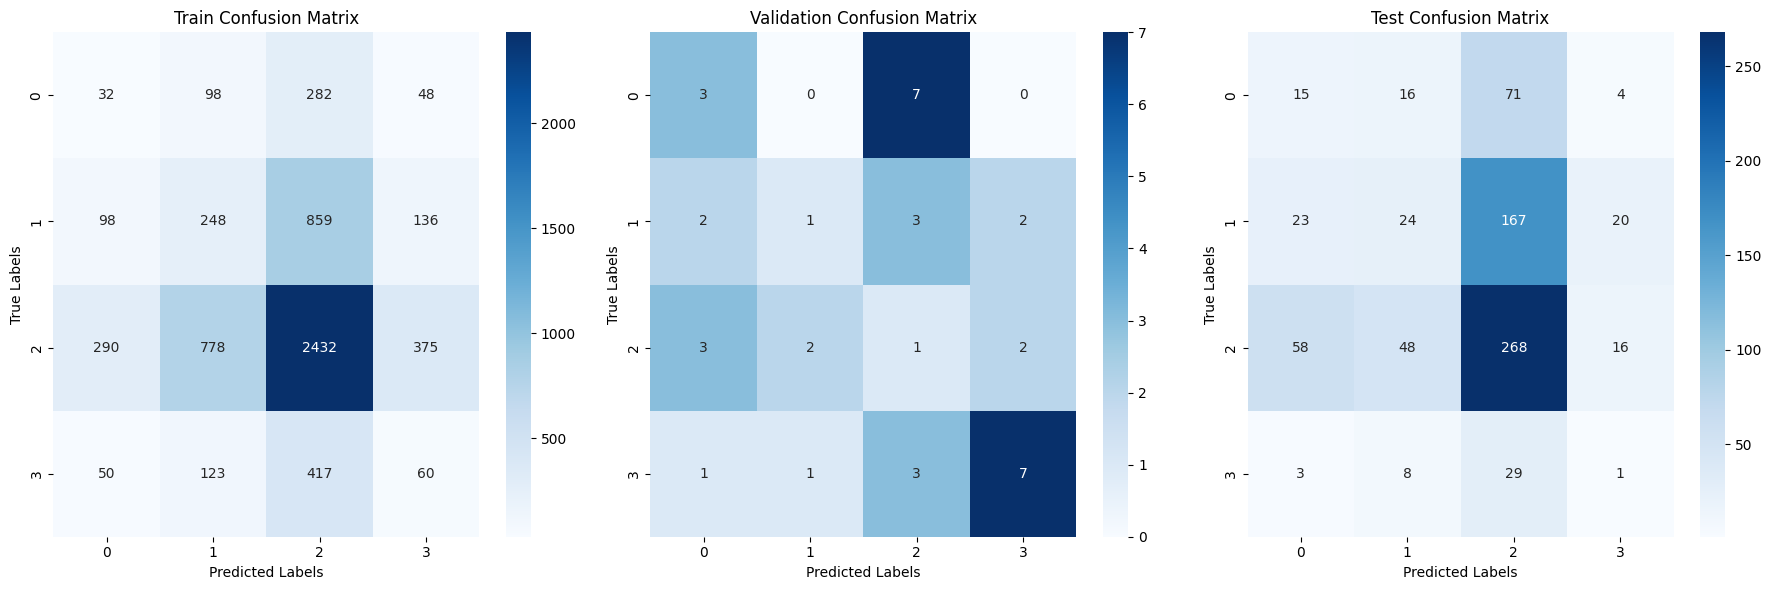

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


# Train Confusion Matrix

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Train Confusion Matrix")
axes[0].set_xlabel("Predicted Labels")
axes[0].set_ylabel("True Labels")


# Validation Confusion Matrix

sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Validation Confusion Matrix")
axes[1].set_xlabel("Predicted Labels")
axes[1].set_ylabel("True Labels")


# Test Confusion Matrix

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title("Test Confusion Matrix")
axes[2].set_xlabel("Predicted Labels")
axes[2].set_ylabel("True Labels")

plt.tight_layout()
plt.show()

## Even more finetuning

In [ ]:
# Load VGG16 with pre-trained ImageNet weights, exclude top layers
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)


# Freeze the first 15 layers
for layer in base_model.layers[:13]:
    layer.trainable = False

# Unfreeze the remaining layers
for layer in base_model.layers[13:]:
    layer.trainable = True

# Optional: check which layers are trainable
for i, layer in enumerate(base_model.layers):
    print(f"Layer {i}: {layer.name}, Trainable: {layer.trainable}")

Layer 0: input_layer_7, Trainable: False
Layer 1: block1_conv1, Trainable: False
Layer 2: block1_conv2, Trainable: False
Layer 3: block1_pool, Trainable: False
Layer 4: block2_conv1, Trainable: False
Layer 5: block2_conv2, Trainable: False
Layer 6: block2_pool, Trainable: False
Layer 7: block3_conv1, Trainable: False
Layer 8: block3_conv2, Trainable: False
Layer 9: block3_conv3, Trainable: False
Layer 10: block3_pool, Trainable: False
Layer 11: block4_conv1, Trainable: False
Layer 12: block4_conv2, Trainable: False
Layer 13: block4_conv3, Trainable: True
Layer 14: block4_pool, Trainable: True
Layer 15: block5_conv1, Trainable: True
Layer 16: block5_conv2, Trainable: True
Layer 17: block5_conv3, Trainable: True
Layer 18: block5_pool, Trainable: True


In [ ]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 9,439,232 (36.01 MB)

 Non-trainable params: 5,275,456 (20.12 MB)

In [ ]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_tensor=Input(shape=(224, 224, 3))
)

base_model2 = VGG16(
    weights="imagenet",
    include_top=True,
    input_tensor=Input(shape=(224, 224, 3))
)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [ ]:
base_model.summary()

In [ ]:
base_model2.summary()